In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")
df = df_train.copy()

## Checking the dataframe structure

In [5]:
df.shape

(59598, 24)

In [6]:
df.dtypes

Employee ID                 int64
Age                         int64
Gender                        str
Years at Company            int64
Job Role                      str
Monthly Income              int64
Work-Life Balance             str
Job Satisfaction              str
Performance Rating            str
Number of Promotions        int64
Overtime                      str
Distance from Home          int64
Education Level               str
Marital Status                str
Number of Dependents        int64
Job Level                     str
Company Size                  str
Company Tenure              int64
Remote Work                   str
Leadership Opportunities      str
Innovation Opportunities      str
Company Reputation            str
Employee Recognition          str
Attrition                     str
dtype: object

In [7]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


## checking dataframe quality

In [8]:
df.isnull().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [11]:
df.describe(include='object')

/var/folders/j8/wn47sn2j7vz_yfzd4kzrgkfr0000gn/T/ipykernel_54916/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,Job Role,Work-Life Balance,Job Satisfaction,Performance Rating,Overtime,Education Level,Marital Status,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
count,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598
unique,2,5,4,4,4,2,5,3,3,3,2,2,2,4,4,2
top,Male,Technology,Good,High,Average,No,Bachelor’s Degree,Married,Entry,Medium,No,No,No,Good,Low,Stayed
freq,32739,15507,22528,29779,35810,40148,17826,29908,23867,29745,48239,56680,49895,29766,23758,31260


In [12]:
# employee id seems
df.drop(columns=['Employee ID'], inplace=True)
df_train.drop(columns=['Employee ID'], inplace=True)
df_test.drop(columns=['Employee ID'], inplace=True)

## Focusing on Target Column

In [13]:
df['Attrition'].value_counts()/len(df)

Attrition
Stayed    0.524514
Left      0.475486
Name: count, dtype: float64

## Univariate

In [14]:
num_cols = ["Age", "Years at Company", "Monthly Income", "Number of Promotions", "Distance from Home", "Number of Dependents", "Company Tenure"]
cat_cols = ["Gender", "Job Role", "Work-Life Balance", "Job Satisfaction", "Performance Rating", "Overtime", "Education Level", "Marital Status", "Job Level", "Company Size", "Remote Work", "Leadership Opportunities", "Innovation Opportunities", "Company Reputation", "Employee Recognition"]

### Numerical

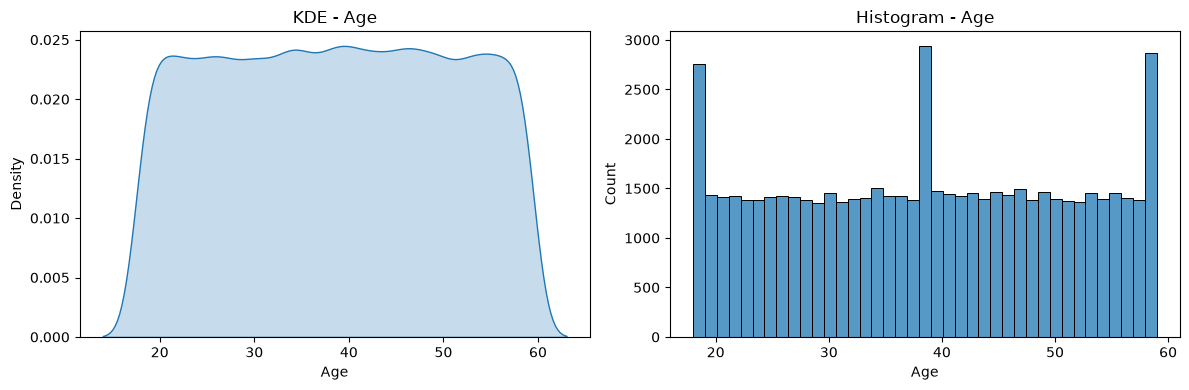

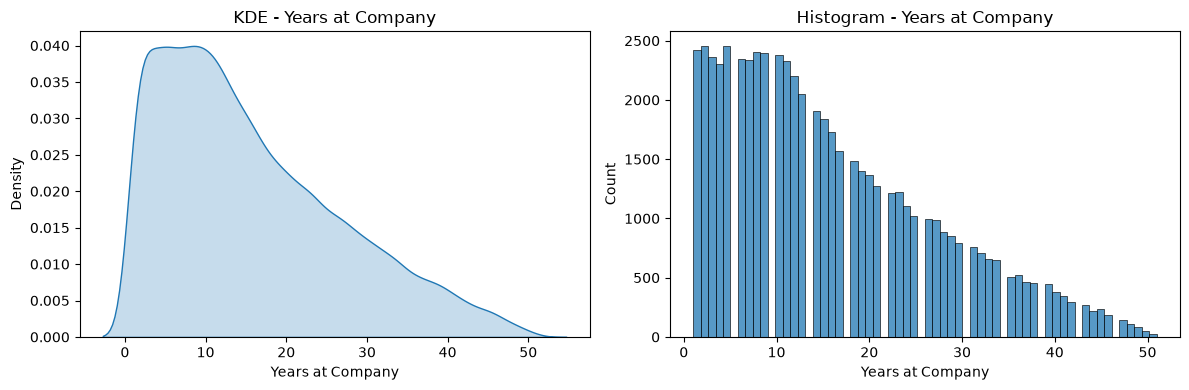

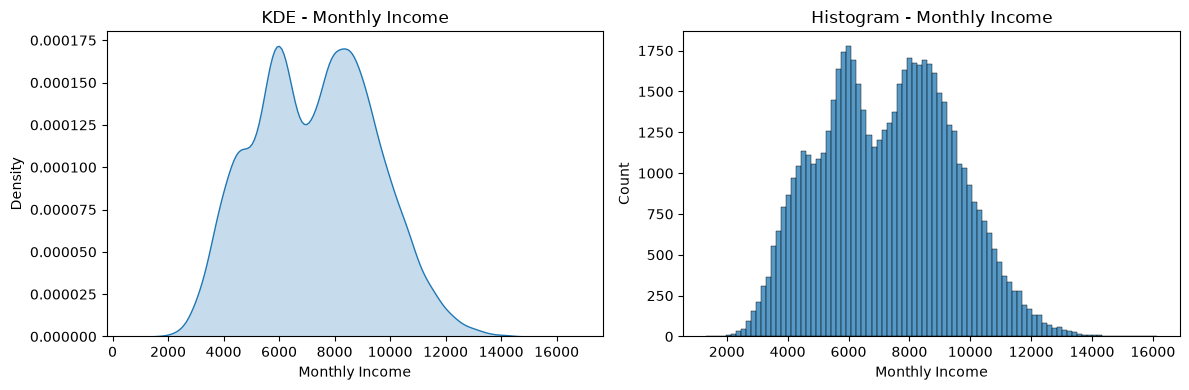

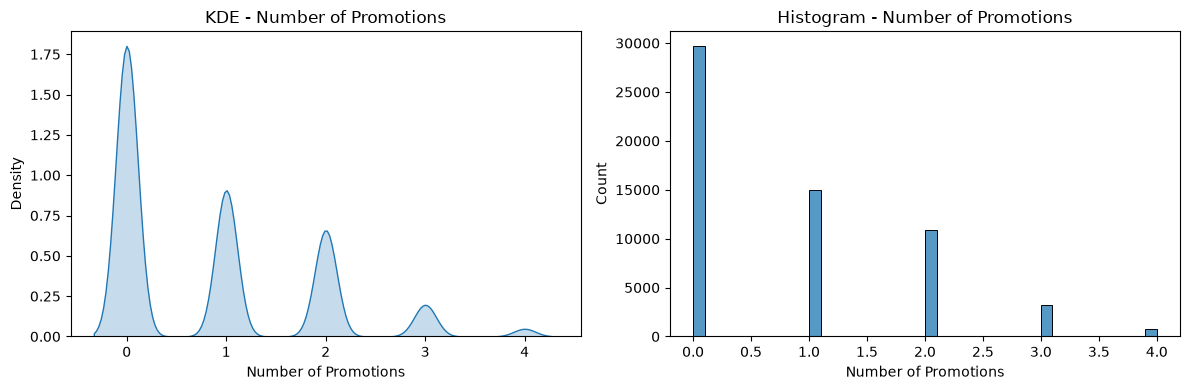

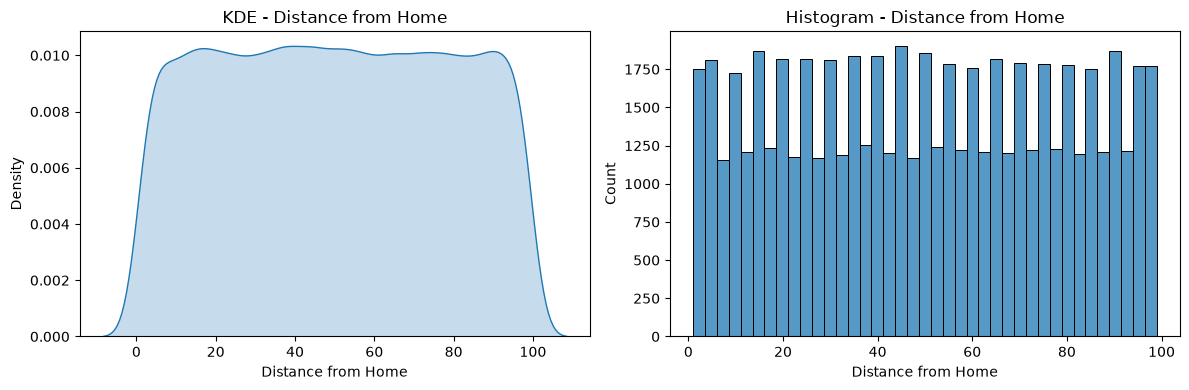

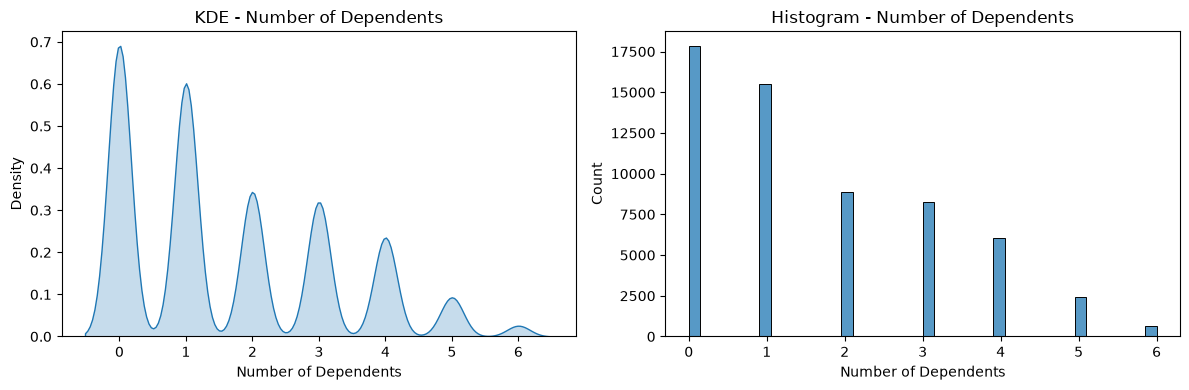

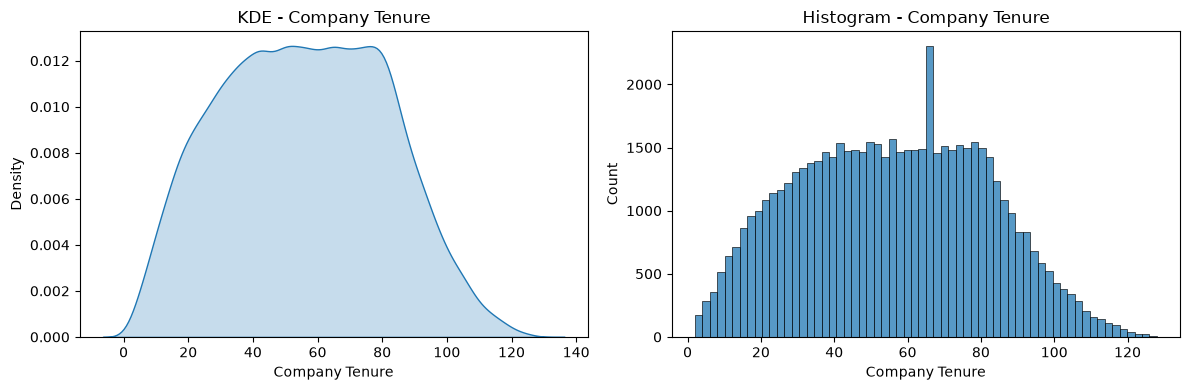

In [15]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # KDE
    sns.kdeplot(data=df,x=col,fill=True,ax=axes[0])
    axes[0].set_title(f"KDE - {col}")

    # Histogram
    sns.histplot(data=df,x=col,ax=axes[1])
    axes[1].set_title(f"Histogram - {col}")

    plt.tight_layout()
    plt.show()

<Axes: ylabel='Density'>

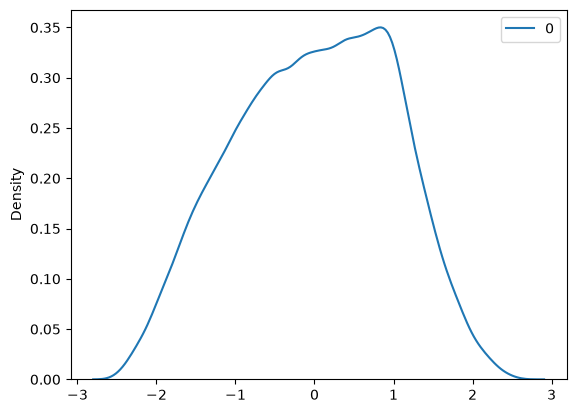

In [16]:
# none working for Company Tenure, So taking it as it is

from sklearn.preprocessing import PowerTransformer,FunctionTransformer
trf = FunctionTransformer(func=np.log1p)
pt = PowerTransformer(method="box-cox")
# xx = trf.fit_transform(df[['Company Tenure']])
# sns.kdeplot(xx)
xx = pt.fit_transform(df[['Company Tenure']])
sns.kdeplot(xx)

### Categorical

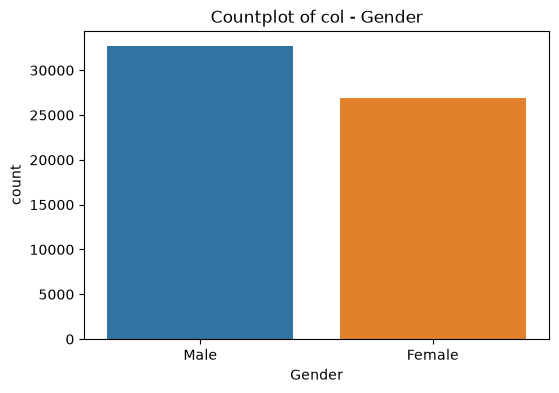

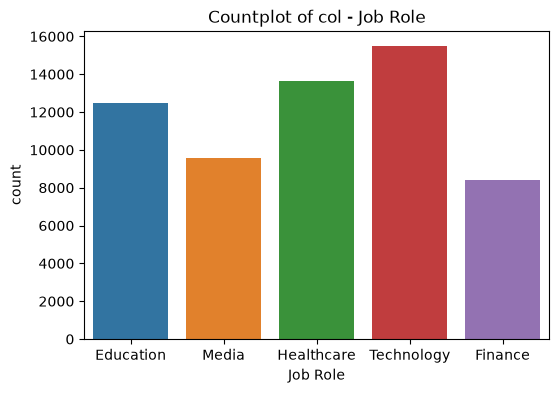

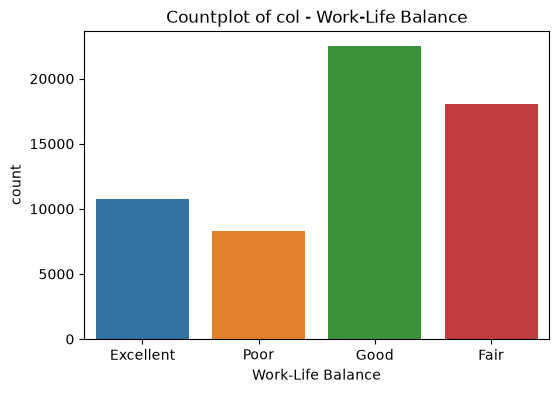

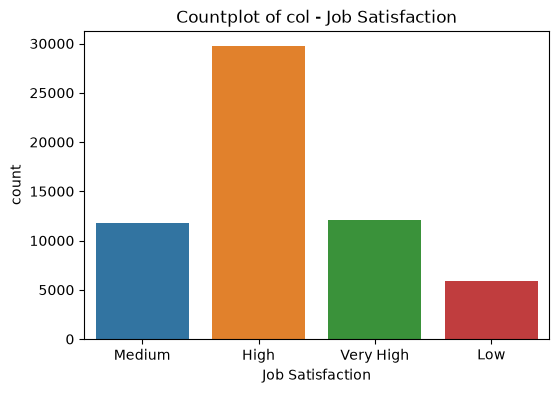

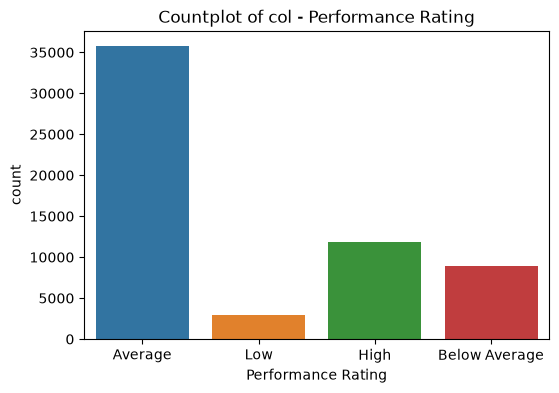

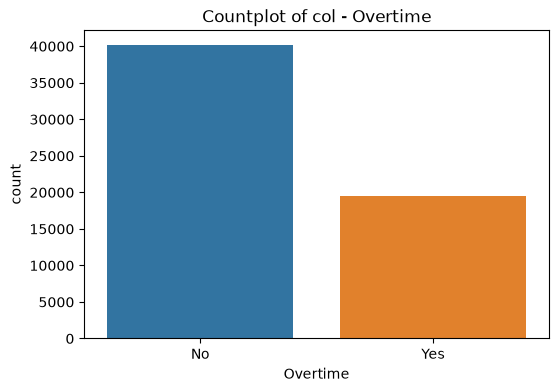

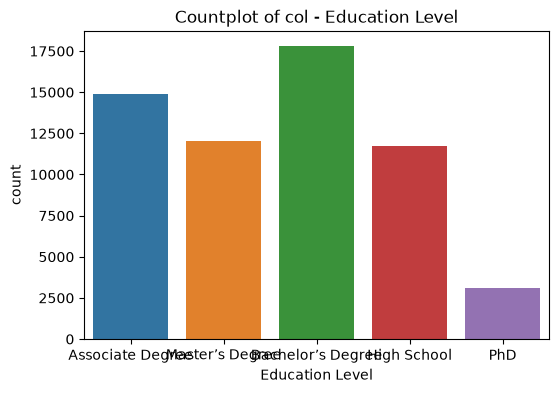

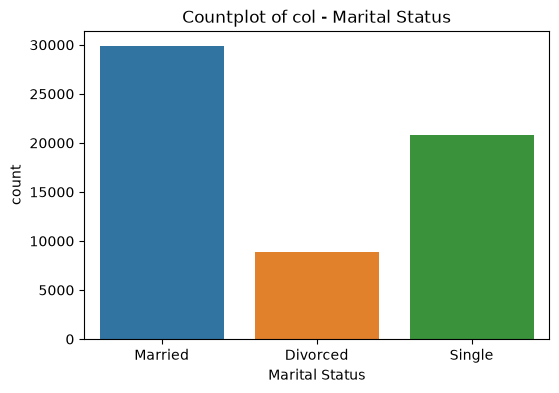

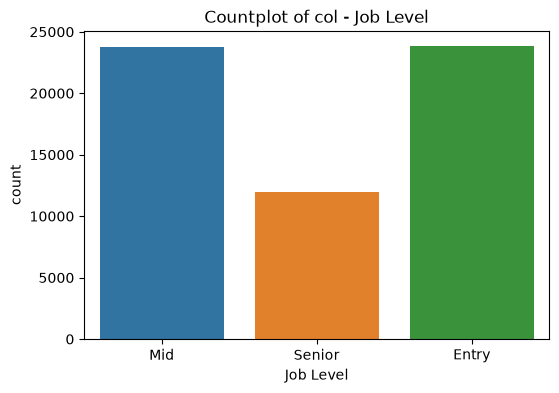

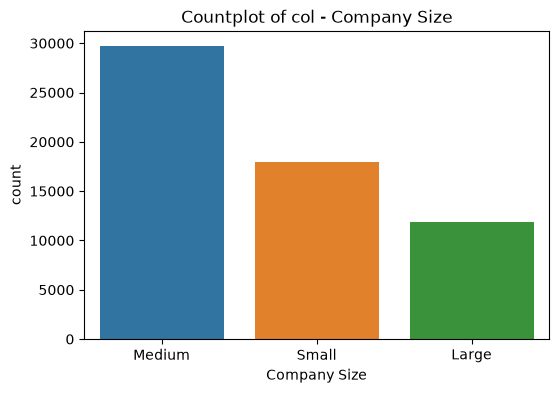

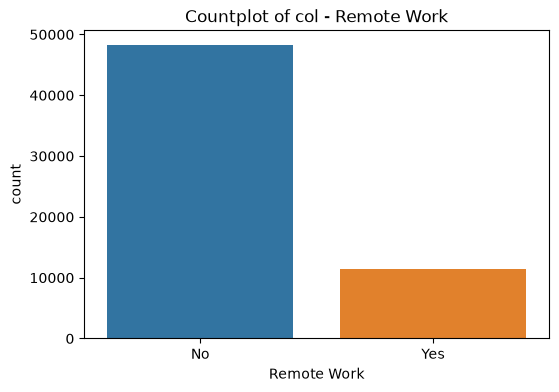

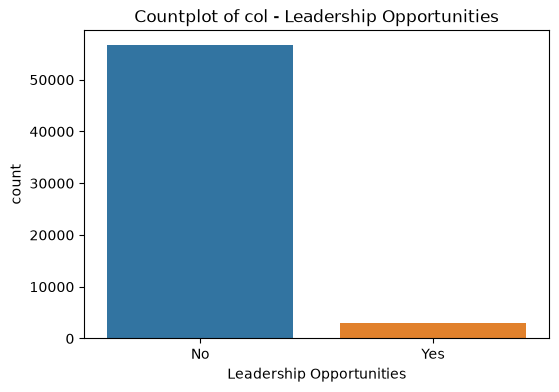

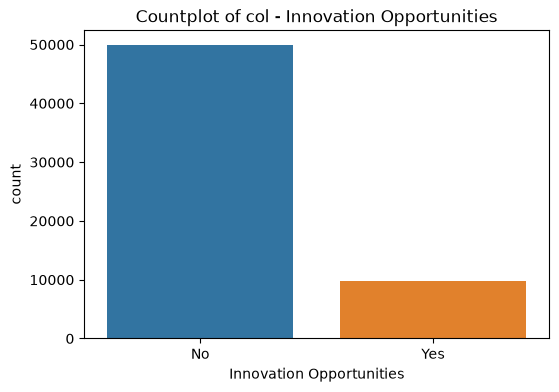

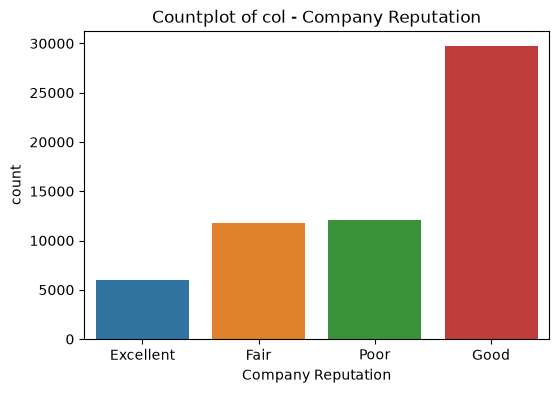

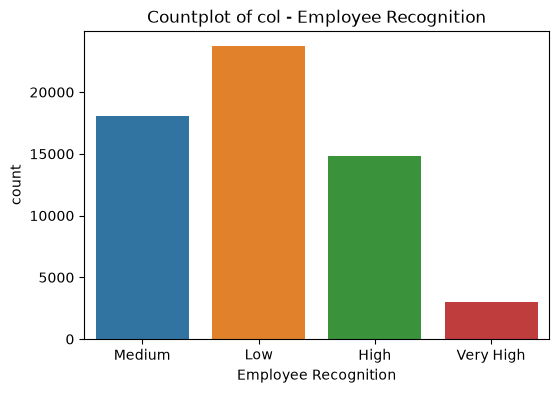

In [17]:
for col in cat_cols:
    fig = plt.subplots(figsize=(6, 4))
    sns.countplot(data = df, x = col, hue = col)
    plt.title(f"Countplot of col - {col}")

## Bivariate

### numerical

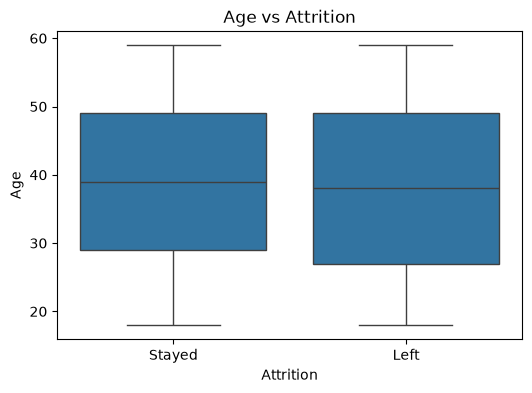

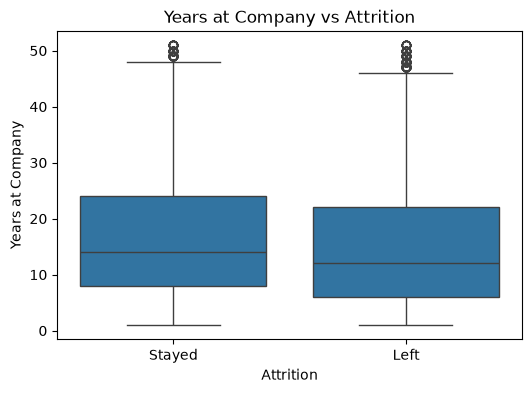

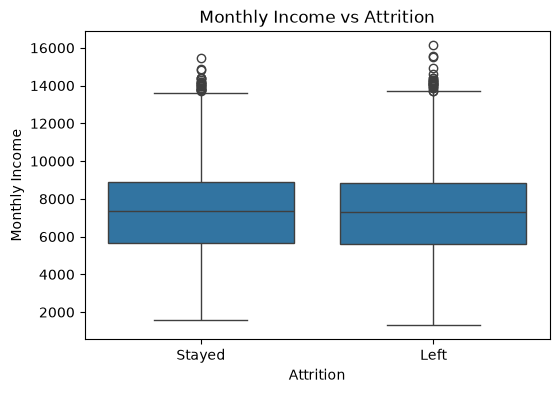

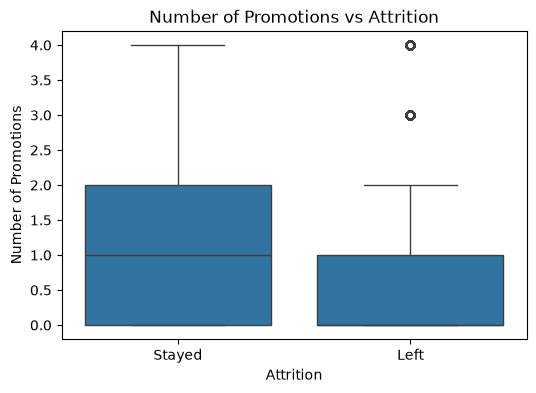

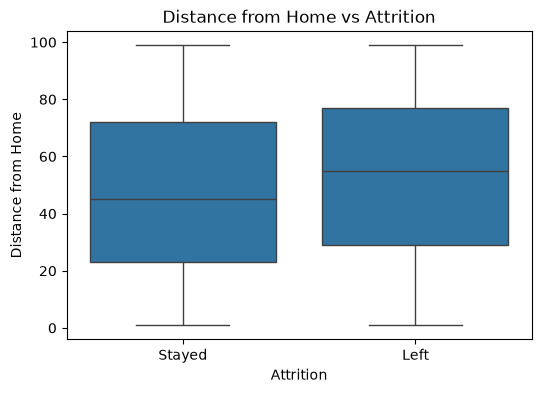

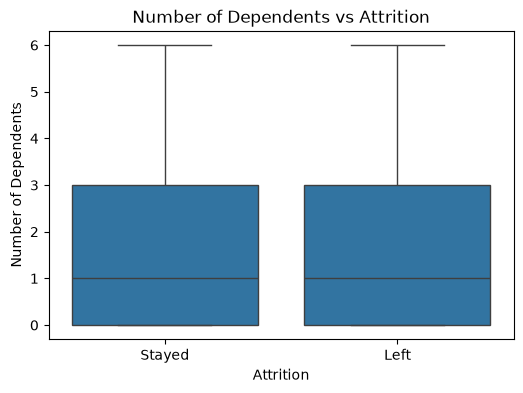

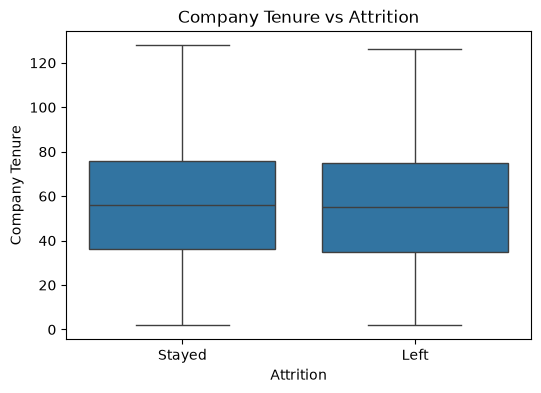

In [18]:
# checking if some column does partiality with the class of output

for col in num_cols:
    plt.figure(figsize=(6,4))

    sns.boxplot(data=df,x="Attrition",y=col)

    plt.title(f"{col} vs Attrition")
    plt.show()

### categorical

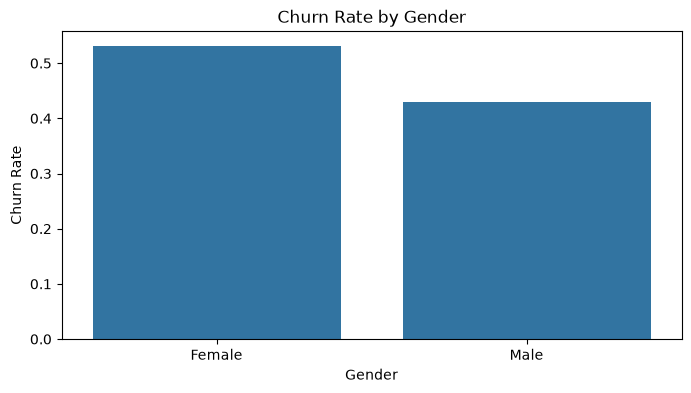

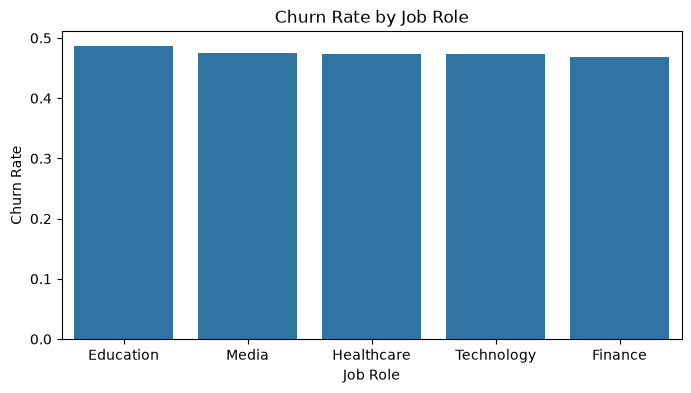

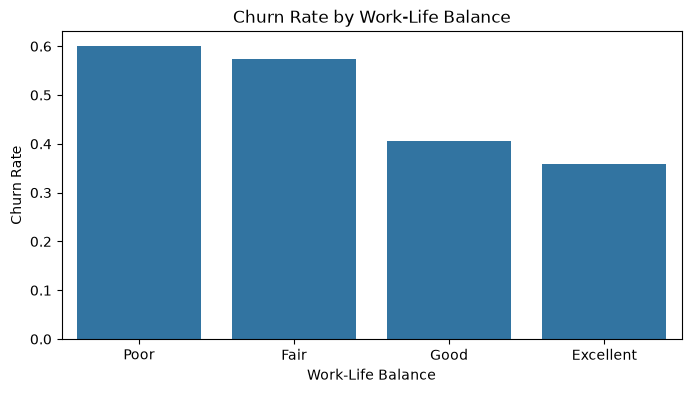

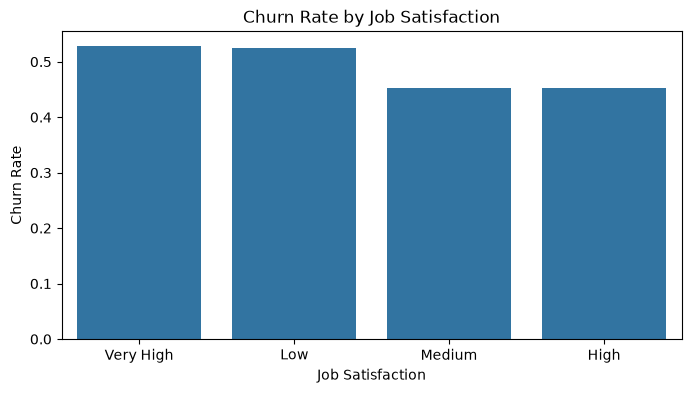

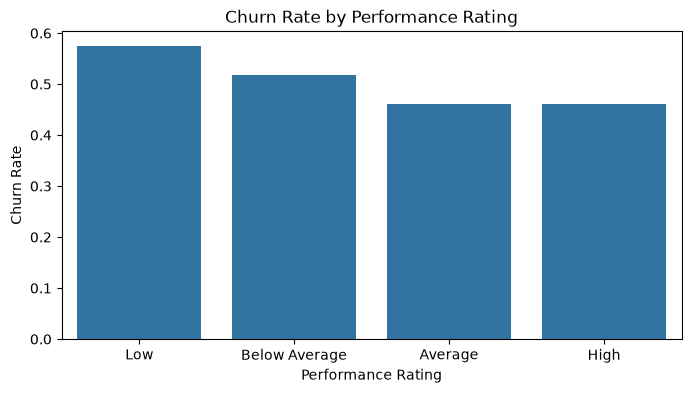

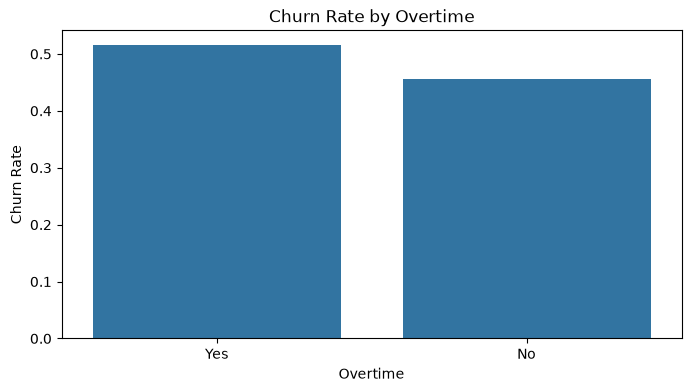

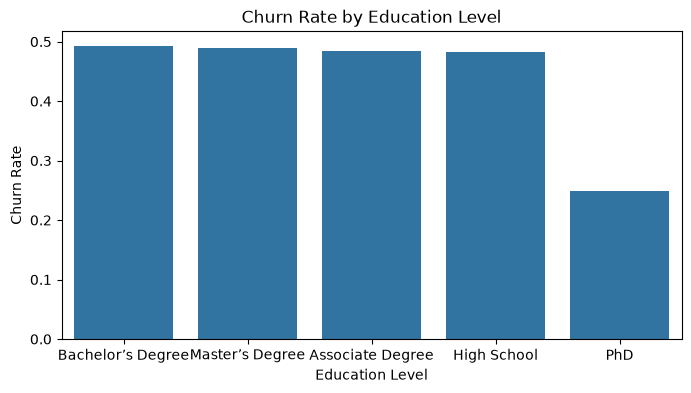

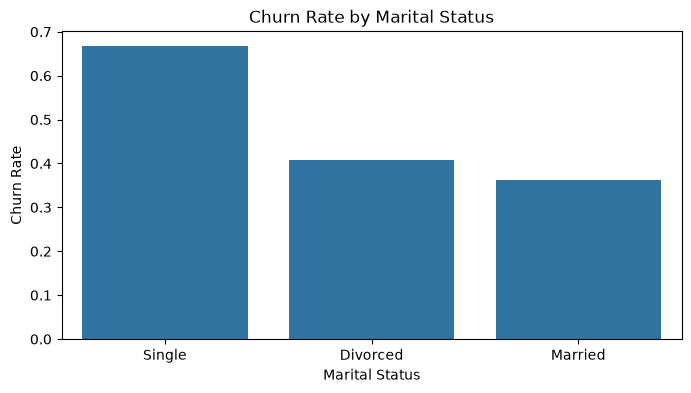

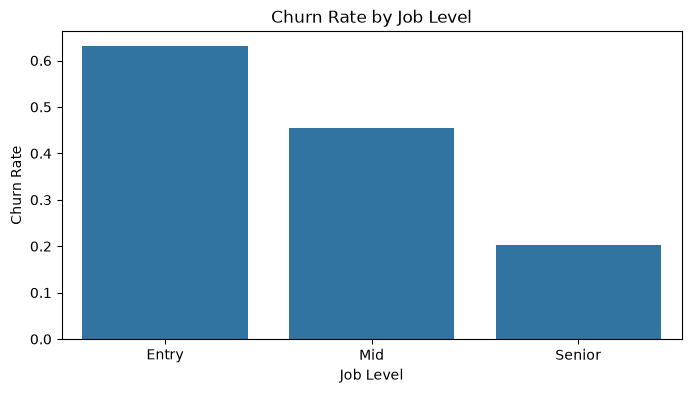

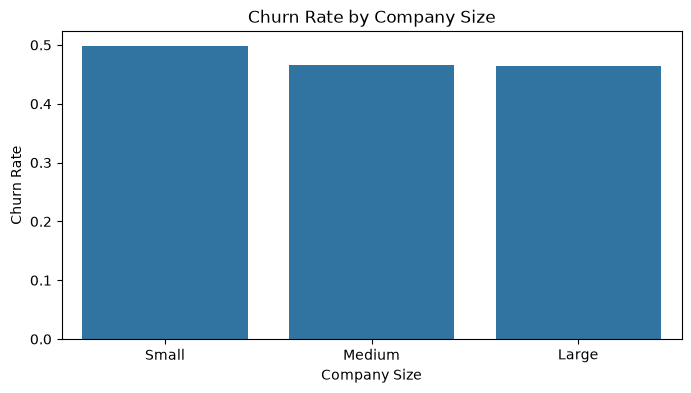

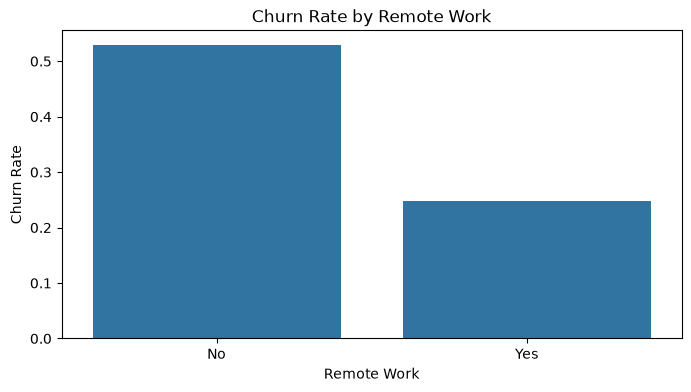

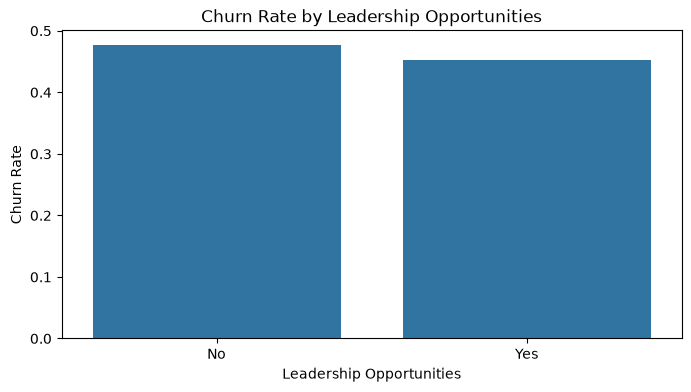

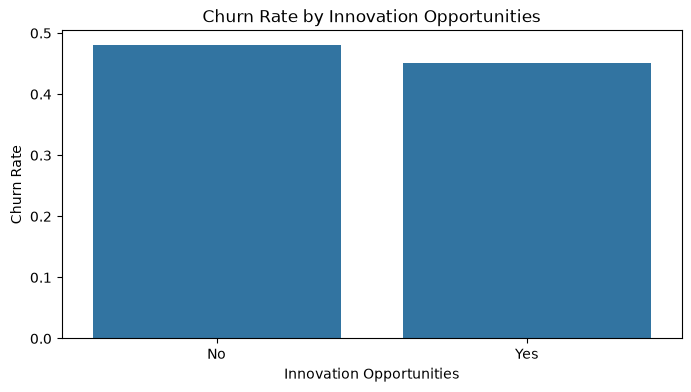

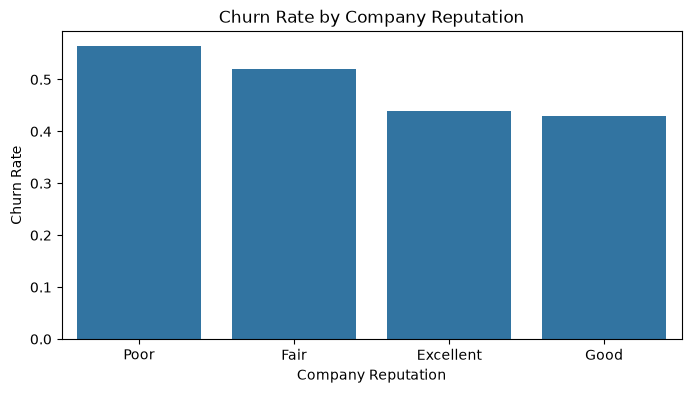

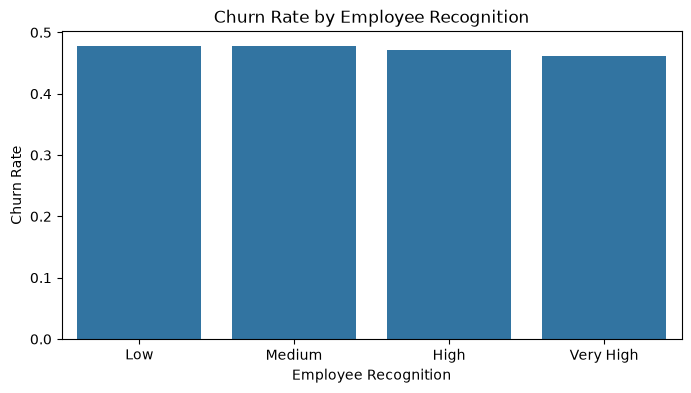

In [19]:
# checking churn rate for each cat col

for col in cat_cols:
    churn_rate = (
        df.groupby(col)["Attrition"]
          .apply(lambda s: (s == "Left").mean())
          .sort_values(ascending=False)
    )

    plt.figure(figsize=(8,4))
    sns.barplot(churn_rate)
    plt.ylabel("Churn Rate")
    plt.title(f"Churn Rate by {col}")
    plt.show()

Gender      Female  Male
Job Role                
Education     5506  6984
Finance       3746  4639
Healthcare    6154  7488
Media         4379  5195
Technology    7074  8433


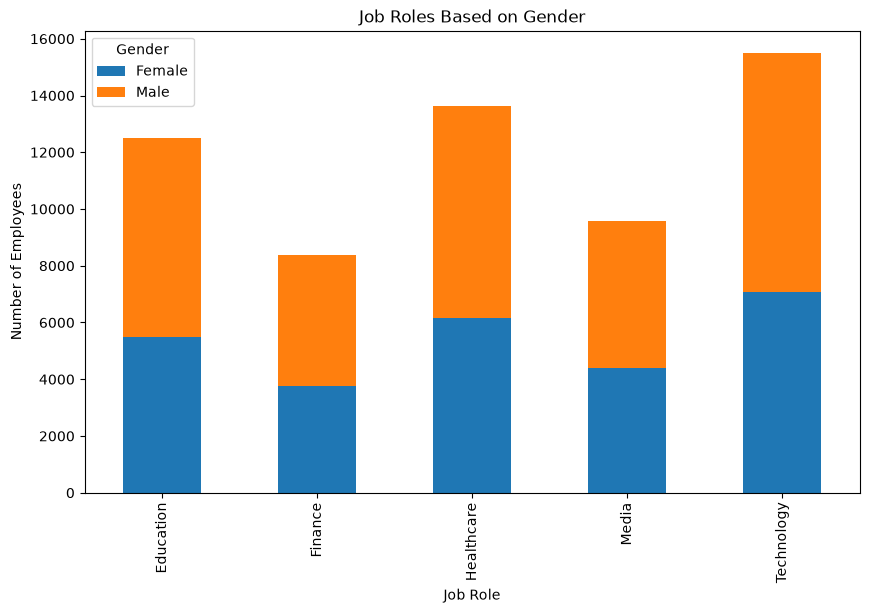

In [20]:
grouped = df.groupby(['Job Role', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar',stacked=True, figsize=(10, 6))
plt.title('Job Roles Based on Gender')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.legend(title='Gender')
plt.show()

Gender             Female   Male
Work-Life Balance               
Excellent            4851   5868
Fair                 8107   9939
Good                10061  12467
Poor                 3840   4465


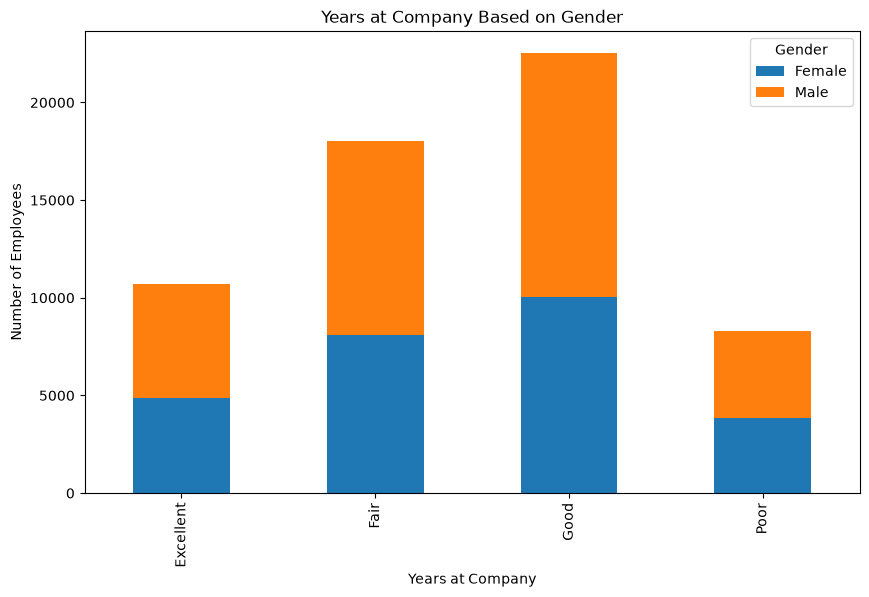

In [21]:
grouped = df.groupby(['Work-Life Balance', 'Gender']).size().unstack(fill_value=0)

print(grouped)
grouped.plot(kind='bar',stacked=True, figsize=(10, 6))
plt.title('Years at Company Based on Gender')
plt.xlabel('Years at Company')
plt.ylabel('Number of Employees')
plt.legend(title='Gender')
plt.show()

## Multi-collinearity

In [22]:
df.corr(numeric_only=True)

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
Age,1.000000,0.539806,-0.001989,0.000167,-0.007063,0.002927,0.237048
Years at Company,0.539806,1.000000,-0.005288,-0.000229,-0.006888,0.003973,0.442180
Monthly Income,-0.001989,-0.005288,1.000000,0.006418,-0.002528,0.002582,-0.005397
Number of Promotions,0.000167,-0.000229,0.006418,1.000000,-0.007882,-0.000558,0.003903
Distance from Home,-0.007063,-0.006888,-0.002528,-0.007882,1.000000,0.000659,-0.005595
Number of Dependents,0.002927,0.003973,0.002582,-0.000558,0.000659,1.000000,0.001600
Company Tenure,0.237048,0.442180,-0.005397,0.003903,-0.005595,0.001600,1.000000


<Axes: >

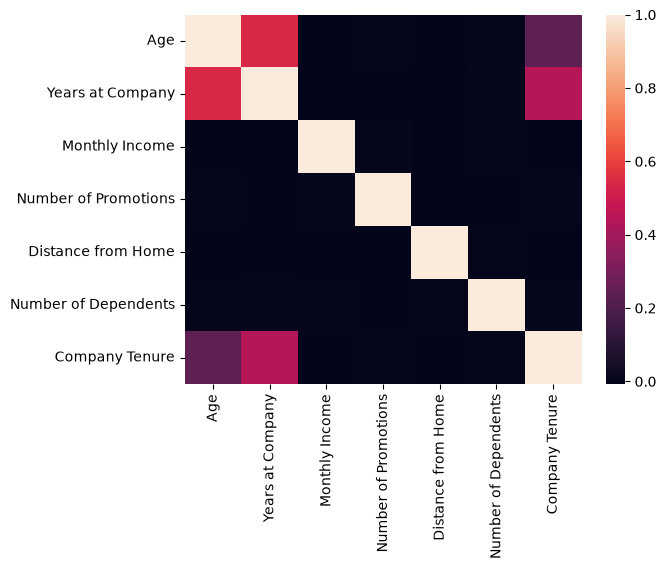

In [23]:
sns.heatmap(df.corr(numeric_only=True))

## Outliers

In [24]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

Age 0
Years at Company 273
Monthly Income 50
Number of Promotions 0
Distance from Home 0
Number of Dependents 0
Company Tenure 0


In [25]:
df.describe()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [26]:
df['Job Satisfaction'].value_counts().index

Index(['High', 'Very High', 'Medium', 'Low'], dtype='str', name='Job Satisfaction')

## Model Training

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from catboost import Pool
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from sklearn import set_config
set_config(transform_output='pandas')

In [28]:
oe = OrdinalEncoder(categories=[['Entry', 'Mid', 'Senior'], ['Poor', 'Fair', 'Good', 'Excellent'], ['Poor', 'Fair', 'Good', 'Excellent'], ['Low', 'Below Average', 'Average', 'High'], ['High School', 'Associate Degree', 'Bachelor’s Degree', 'Master’s Degree', 'PhD'], ['Small', 'Medium', 'Large'], ['Low', 'Medium', 'High', 'Very High'], ['Low', 'Medium', 'High', 'Very High']], handle_unknown='use_encoded_value', unknown_value=-1)
ohe = OneHotEncoder(sparse_output=False)

ordinal_enc_cols = ['Job Level', 'Work-Life Balance', 'Company Reputation', 'Performance Rating', 'Education Level', 'Company Size', 'Job Satisfaction', 'Employee Recognition']
nominal_enc_cols = ['Gender', 'Job Role', 'Marital Status', 'Overtime', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities']
num_cols = ['Age','Years at Company','Monthly Income','Distance from Home','Company Tenure']

ct = ColumnTransformer(transformers=[
    ('ordinal_enc', oe, ordinal_enc_cols),
    ('nominal_enc', ohe, nominal_enc_cols),
    ('stnd_scale', StandardScaler(), num_cols),
    ('label_enc', OrdinalEncoder(), ['Attrition']),
], verbose_feature_names_out=False, remainder="passthrough")

In [29]:
df_train_trf = ct.fit_transform(df_train)
df_test_trf = ct.transform(df_test)

In [30]:
df_train_trf.shape

(59598, 34)

In [31]:
print(type(df_train_trf))

<class 'pandas.DataFrame'>


In [32]:
X_train = df_train_trf.drop(columns=['Attrition'])
X_test = df_test_trf.drop(columns=['Attrition'])

y_train = df_train_trf['Attrition']
y_test = df_test_trf['Attrition']

### trying Random Forest

In [33]:
rfc = RandomForestClassifier(n_estimators=500, max_depth=15, random_state=42)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7532214765100671

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.74      0.73      0.74      7032
         1.0       0.76      0.77      0.77      7868

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900



In [35]:
df['Attrition'].value_counts()

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

In [36]:
df.describe()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [37]:
models = [LogisticRegression(max_iter=5000, verbose=False),DecisionTreeClassifier(),RandomForestClassifier(),XGBClassifier(),CatBoostClassifier(verbose=False)]
for model in models:
    print(f'{model} -> {np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='accuracy'))}')
    print(f'{model} -> {np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='f1'))}')

LogisticRegression(max_iter=5000, verbose=False) -> 0.7399744190511905
LogisticRegression(max_iter=5000, verbose=False) -> 0.7536333767761754
DecisionTreeClassifier() -> 0.6684788584128549
DecisionTreeClassifier() -> 0.6834627244744567
RandomForestClassifier() -> 0.7461491606374346
RandomForestClassifier() -> 0.7561226941894522
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_

### trying catbooost with CAT cols

In [38]:
cat = CatBoostClassifier()

X_train = df_train.drop(columns=['Attrition'])
X_test = df_test.drop(columns=['Attrition'])

y_train = df_train['Attrition']
y_test = df_test['Attrition']

pool_train = Pool(X_train,y_train,cat_features=cat_cols)
pool_test = Pool(X_test,cat_features=cat_cols)
cat.fit(pool_train)
accuracy_score(y_test, cat.predict(pool_test))

Learning rate set to 0.059014
0:	learn: 0.6701619	total: 14.6ms	remaining: 14.5s
1:	learn: 0.6506546	total: 23.9ms	remaining: 11.9s
2:	learn: 0.6338803	total: 32.4ms	remaining: 10.8s
3:	learn: 0.6198303	total: 42.3ms	remaining: 10.5s
4:	learn: 0.6061493	total: 50.9ms	remaining: 10.1s
5:	learn: 0.5946953	total: 58.3ms	remaining: 9.65s
6:	learn: 0.5847342	total: 66.1ms	remaining: 9.38s
7:	learn: 0.5760712	total: 73.2ms	remaining: 9.07s
8:	learn: 0.5691278	total: 82.3ms	remaining: 9.06s
9:	learn: 0.5626032	total: 90.5ms	remaining: 8.96s
10:	learn: 0.5569068	total: 99.4ms	remaining: 8.94s
11:	learn: 0.5519911	total: 110ms	remaining: 9.02s
12:	learn: 0.5478931	total: 122ms	remaining: 9.24s
13:	learn: 0.5439152	total: 131ms	remaining: 9.19s
14:	learn: 0.5400122	total: 140ms	remaining: 9.18s
15:	learn: 0.5365151	total: 149ms	remaining: 9.15s
16:	learn: 0.5327541	total: 157ms	remaining: 9.07s
17:	learn: 0.5294356	total: 167ms	remaining: 9.12s
18:	learn: 0.5268356	total: 176ms	remaining: 9.11s


0.7607382550335571

## Feature Engineering

In [39]:
def feature_engineer(df):
      df['promotions_per_year'] = df['Number of Promotions'] / (df['Years at Company'] + 1)   # career stagnation
      df['tenure_ratio']        = df['Years at Company'] / (df['Company Tenure'] + 1)          # loyalty / share of career here
      df['age_at_joining']      = df['Age'] - df['Years at Company']                           # joined young vs late-career
      df['income_per_dependent']= df['Monthly Income'] / (df['Number of Dependents'] + 1)      # financial pressure
      df['effective_distance'] = df['Distance from Home'] * (df['Remote Work'] == 'No')

In [40]:
feature_engineer(df_train)
feature_engineer(df_test)
df_train.columns

Index(['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income',
       'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
       'Number of Promotions', 'Overtime', 'Distance from Home',
       'Education Level', 'Marital Status', 'Number of Dependents',
       'Job Level', 'Company Size', 'Company Tenure', 'Remote Work',
       'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition',
       'promotions_per_year', 'tenure_ratio', 'age_at_joining',
       'income_per_dependent', 'effective_distance'],
      dtype='str')

In [41]:
df_train_trf = ct.fit_transform(df_train)
df_test_trf = ct.transform(df_test)

X_train = df_train_trf.drop(columns=['Attrition'])
X_test = df_test_trf.drop(columns=['Attrition'])

y_train = df_train_trf['Attrition']
y_test = df_test_trf['Attrition']

In [42]:
models = [LogisticRegression(max_iter=5000),DecisionTreeClassifier(),RandomForestClassifier(),XGBClassifier(),CatBoostClassifier(verbose=False)]
for model in models:
    print(f'{model} -> {np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='accuracy'))}')
    print(f'{model} -> {np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='f1'))}')

/Users/kris/Developer/mystuff/Employee_Churn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kris/Developer/mystuff/Employee_Churn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:

LogisticRegression(max_iter=5000) -> 0.7403771374000454


/Users/kris/Developer/mystuff/Employee_Churn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kris/Developer/mystuff/Employee_Churn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:

LogisticRegression(max_iter=5000) -> 0.7539462470685259
DecisionTreeClassifier() -> 0.6687137366260287
DecisionTreeClassifier() -> 0.6856907606693932
RandomForestClassifier() -> 0.7428772612787322
RandomForestClassifier() -> 0.7577952506952574
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, .

### trying Voting Ensemble

In [43]:
model = VotingClassifier(
    estimators=[
        ("cat", CatBoostClassifier()),
        ("xgb", XGBClassifier()),
        ("rf", RandomForestClassifier())
    ],
    voting="soft"
)

model.fit(X_train,y_train)

Learning rate set to 0.059014
0:	learn: 0.6694998	total: 3.81ms	remaining: 3.81s
1:	learn: 0.6491471	total: 7.06ms	remaining: 3.52s
2:	learn: 0.6317251	total: 10.4ms	remaining: 3.46s
3:	learn: 0.6169257	total: 14.1ms	remaining: 3.5s
4:	learn: 0.6036103	total: 17.2ms	remaining: 3.43s
5:	learn: 0.5925544	total: 20.7ms	remaining: 3.42s
6:	learn: 0.5829448	total: 23.8ms	remaining: 3.38s
7:	learn: 0.5751722	total: 27ms	remaining: 3.35s
8:	learn: 0.5678603	total: 30.6ms	remaining: 3.36s
9:	learn: 0.5616683	total: 33.8ms	remaining: 3.34s
10:	learn: 0.5553179	total: 37.6ms	remaining: 3.38s
11:	learn: 0.5505562	total: 40.7ms	remaining: 3.35s
12:	learn: 0.5459515	total: 44.4ms	remaining: 3.37s
13:	learn: 0.5421458	total: 47.8ms	remaining: 3.37s
14:	learn: 0.5378224	total: 51.1ms	remaining: 3.35s
15:	learn: 0.5337020	total: 54.5ms	remaining: 3.35s
16:	learn: 0.5303768	total: 57.8ms	remaining: 3.34s
17:	learn: 0.5277333	total: 61.2ms	remaining: 3.34s
18:	learn: 0.5252005	total: 64.3ms	remaining: 3

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[float64](2,)","[0.,1.]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[CatBoostClassifier(), XGBClassifier...ree=None, ...), RandomForestClassifier()]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](38,)","['Job Level','Work-Life Balance','Company Reputation',...,'age_at_joining', 'income_per_dependent','effective_distance']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [44]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7555704697986577

## CATBOOST has the best performance

### creating a pipeline with first feature engineering, then preprocessing, and then model

In [45]:
from src.preprocessing import feature_engineer

feature_transformer = FunctionTransformer(feature_engineer,validate=False)

In [46]:
oe = OrdinalEncoder(categories=[['Entry', 'Mid', 'Senior'], ['Poor', 'Fair', 'Good', 'Excellent'], ['Poor', 'Fair', 'Good', 'Excellent'], ['Low', 'Below Average', 'Average', 'High'], ['High School', 'Associate Degree', 'Bachelor’s Degree', 'Master’s Degree', 'PhD'], ['Small', 'Medium', 'Large'], ['Low', 'Medium', 'High', 'Very High'], ['Low', 'Medium', 'High', 'Very High']], handle_unknown='use_encoded_value', unknown_value=-1)
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

ordinal_enc_cols = ['Job Level', 'Work-Life Balance', 'Company Reputation', 'Performance Rating', 'Education Level', 'Company Size', 'Job Satisfaction', 'Employee Recognition']
nominal_enc_cols = ['Gender', 'Job Role', 'Marital Status', 'Overtime', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities']

preprocess_transformer = ColumnTransformer(transformers=[
    ('ordinal_enc', oe, ordinal_enc_cols),
    ('nominal_enc', ohe, nominal_enc_cols),
], verbose_feature_names_out=False, remainder="passthrough")

In [47]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('feature_engineering', feature_transformer),
    ('preprocessor', preprocess_transformer),
    ('model', CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

In [48]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")
X_train = df_train.drop(columns=['Attrition'])
X_test = df_test.drop(columns=['Attrition'])

# 1 = churned, 0 = stayed
y_train = (df_train['Attrition'] == 'Left').astype(int)   
y_test  = (df_test['Attrition']  == 'Left').astype(int)

In [49]:
pipeline.fit(X_train,y_train)

y_pred = pipeline.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.7595973154362416


In [ ]:
# checking if the model didnyt overfit

print('train:', pipeline.score(X_train, y_train))
print('test :', pipeline.score(X_test, y_test))

train: 0.8096748213027283
test : 0.7595973154362416


In [51]:
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77      7868
           1       0.74      0.75      0.75      7032

    accuracy                           0.76     14900
   macro avg       0.76      0.76      0.76     14900
weighted avg       0.76      0.76      0.76     14900

ROC-AUC: 0.8506098636605237


In [52]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
  'model__depth':         [4, 6, 8],
  'model__learning_rate': [0.03, 0.05, 0.1],
  'model__l2_leaf_reg':   [3, 5, 7],
  # iterations NOT here — fixed high, controlled by early stopping
}

search = RandomizedSearchCV(
  estimator=pipeline,        # CatBoost already set to iterations=2000, verbose=0
  param_distributions=param_dist,
  n_iter=15,                 # 15 combos instead of 81
  scoring='f1',
  cv=3,                      
  n_jobs=-1,
  verbose=1,                 # 1 = progress without the wall of text
  random_state=42,
)
search.fit(X_train, y_train)
print(search.best_params_, search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'model__learning_rate': 0.03, 'model__l2_leaf_reg': 3, 'model__depth': 4} 0.7462506696227097


## Exporting the model

In [54]:
import joblib

joblib.dump(pipeline, "model/model.pkl")

['model/model.pkl']